In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator, RBFInterpolator

sys.path.append('/')
from control.experiment_data import ExperimentData
from control.database import DatabaseHandler

# Исходные данные

In [3]:
db = DatabaseHandler()
df = db.get_all_experiment_data()

diesel_air = df.loc[(df['fuel_id'] == 1) & (df['F_air'].notna())]
diesel_steam = df.loc[(df['fuel_id'] == 1) & (df['F_steam'].notna())]

crude_oil_steam = df.loc[(df['fuel_id'] == 2) & (df['F_steam'].notna())]

heavy_oil_air = df.loc[(df['fuel_id'] == 3) & (df['F_air'].notna())]
heavy_oil_steam = df.loc[(df['fuel_id'] == 3) & (df['F_steam'].notna())]

kerosene_air = df.loc[(df['fuel_id'] == 4) & (df['F_air'].notna())]
kerosene_steam = df.loc[(df['fuel_id'] == 4) & (df['F_steam'].notna())]

waste_oil_steam = df.loc[(df['fuel_id'] == 5) & (df['F_steam'].notna())]

dfs = {
    'diesel_air': diesel_air, 
    'diesel_steam': diesel_steam, 
    'crude_oil_steam': crude_oil_steam, 
    'heavy_oil_air': heavy_oil_air, 
    'heavy_oil_steam': heavy_oil_steam, 
    'kerosene_air': kerosene_air, 
    'kerosene_steam': kerosene_steam, 
    'waste_oil_steam': waste_oil_steam
}

# Суммарное значение воздуха

In [4]:
sum_air_coef = {
    'diesel': 14.431,
    'crude_oil': 13.775,
    'heavy_oil': 13.660,
    'kerosene': 14.523,
    'waste_oil': 14.408
}

for key in dfs:
    if key.count('_') == 1:
        fuel_type = key.split('_')[0]
        dfs[key] = dfs[key].copy()
        dfs[key].loc[:, 'sum_air'] = dfs[key]['F_fuel'] * sum_air_coef[fuel_type] * 21 / (21 - dfs[key]['O2'])
    else:
        fuel_type = key.split('_')[0] + '_' + key.split('_')[1]
        dfs[key] = dfs[key].copy()
        dfs[key].loc[:, 'sum_air'] = dfs[key]['F_fuel'] * sum_air_coef[fuel_type] * 21 / (21 - dfs[key]['O2'])


# Импульс струи

## Расчет струи

In [5]:
steam_params = pd.DataFrame({
    "Cp": [2.139108184, 2.079572787],  # теплоемкость (Дж/(кг*К)) Cp
    "adiabat": [1.302022264, None],  # показатель адиабаты kg
    "mol_mass": [0.018, None],  # молярная масса (кг/моль)
    "G": [0.000222222, None],  # mass flowrate (kg/s) G
    "G_hr": [0.8, None],  # mass flowrate (кг/ч) G_hr
    "D_tube": [0.003, None],  # диаметр отверстия трубки
    "D_jet": [0.0006, None],  # диаметр отверстия форсунки
    "P": [7.4, 1.01],  # P (bar)
    "T": [523.15, 329.6083348],  # T (K)
    "t": [250, 56.60833484],  # t_C (C)
    "rho": [3.063916824, 0.663734924],  # rho (kg/m3)
    "U": [10.26072679, 931.3243951],  # U (m/s)
    "Q": [4.351728228, 20.08834076],  # Q (л/мин)
    "Y_jet": [0.002280162, 0.207]  # Yjet (N)
}, index=["input_tube", "jet"]
)

air_params = pd.DataFrame({
    "Cp": [1.006, 1.006],  # теплоемкость (Дж/(кг*К)) Cp
    "adiabat": [1.4, None],  # показатель адиабаты kg
    "mol_mass": [0.029, None],  # молярная масса (кг/моль)
    "G": [0.000287778, None],  # mass flowrate (kg/s) G
    "G_hr": [1.036, None],  # mass flowrate (кг/ч) G_hr
    "D_tube": [0.003, None],  # диаметр отверстия трубки
    "D_jet": [0.0006, None],  # диаметр отверстия форсунки
    "P": [7.8, 1.01],  # P (bar)
    "T": [523.15, 291.7270737],  # T (K)
    "t": [250, 18.72707372],  # t_C (C)
    "rho": [5.20313803, 1.208207736],  # rho (kg/m3)
    "U": [7.824552641, 682.4105445],  # U (m/s)
    "Q": [3.318510208, 14.29114063],  # Q (л/мин)
    "Y_jet": [0.002251732, 0.196]  # Yjet (N)
}, index=["input_tube", "jet"])


## Струя выбросы

In [6]:
for key in dfs:
    st_prm_tube = steam_params.loc['input_tube']
    st_prm_jet = steam_params.loc['jet']

    air_prm_tube = air_params.loc['input_tube']
    air_prm_jet = air_params.loc['jet']
    
    if 'steam' in key:
        dfs[key] = dfs[key].copy()
        
        P_abs = 7.8 * dfs[key]['F_steam']
        ro_tube = P_abs * 100_000 * st_prm_tube['mol_mass'] / st_prm_tube['T'] / 8.31
        ro_atm = ((st_prm_jet['P'] / P_abs) ** (1 / st_prm_tube['adiabat'])) * ro_tube
        T_atm = st_prm_jet['P'] * 100_000 / ro_atm / 8.31 * st_prm_tube['mol_mass']
        U_tube = dfs[key]['F_steam'] / 3_600 / np.pi / ro_tube / st_prm_tube['D_tube'] / st_prm_tube['D_tube'] * 4
        U_atm = np.sqrt(-2 * st_prm_jet['Cp'] * 1_000 * T_atm + U_tube * U_tube + 2 * st_prm_tube['Cp'] * 1_000 * st_prm_tube['T'])
        dfs[key].loc[:, 'J'] = U_atm * dfs[key]['F_steam'] / 3_600
        
    else:
        dfs[key] = dfs[key].copy()
        
        P_abs = 7.8 * dfs[key]['F_air']
        ro_tube = P_abs * 100_000 * air_prm_tube['mol_mass'] / air_prm_tube['T'] / 8.31
        ro_atm = ((air_prm_jet['P'] / P_abs) ** (1 / air_prm_tube['adiabat'])) * ro_tube
        T_atm = air_prm_jet['P'] * 100_000 / ro_atm / 8.31 * air_prm_tube['mol_mass']
        U_tube = dfs[key]['F_air'] / 3_600 / np.pi / ro_tube / air_prm_tube['D_tube'] / air_prm_tube['D_tube'] * 4
        U_atm = np.sqrt(-2 * air_prm_jet['Cp'] * 1_000 * T_atm + U_tube * U_tube + 2 * air_prm_tube['Cp'] * 1_000 * air_prm_tube['T'])
        dfs[key].loc[:, 'J'] = U_atm * dfs[key]['F_air'] / 3_600
        

# Построение графиков

In [7]:
dfs['diesel_steam'] = dfs['diesel_steam'].round(3)
pivoted = dfs['diesel_steam'].pivot_table(index='J', values='sum_air', columns='F_fuel')

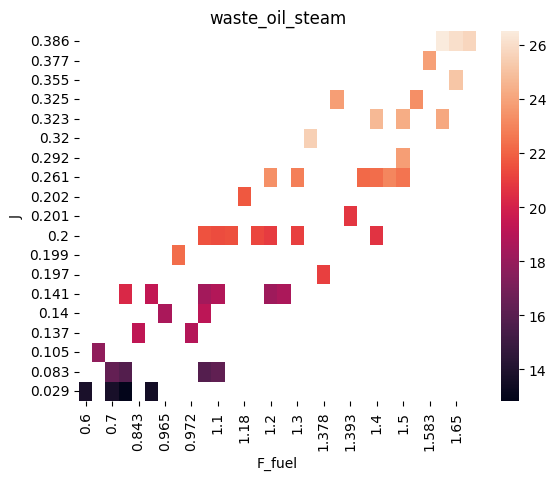

In [8]:
ax = sns.heatmap(data=pivoted)

ax.set_title('waste_oil_steam')

ax.invert_yaxis()

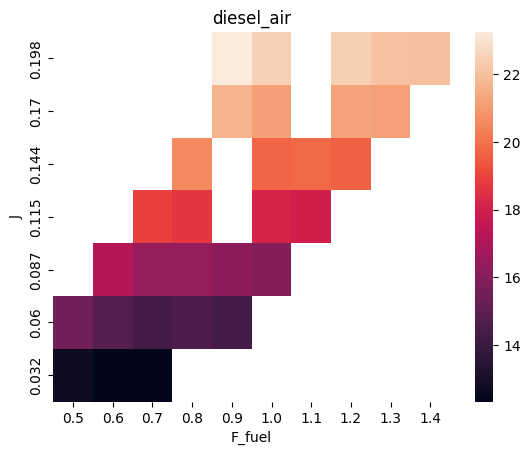

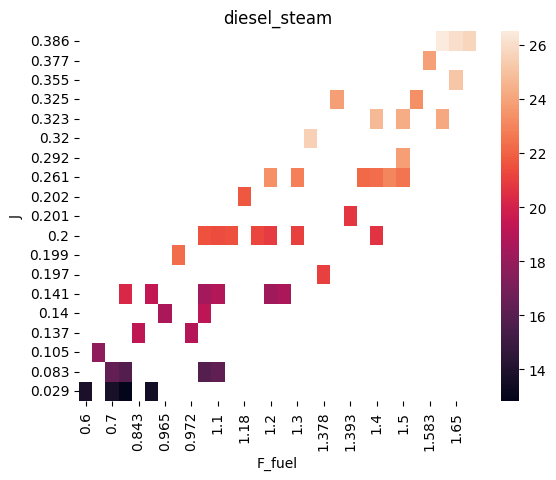

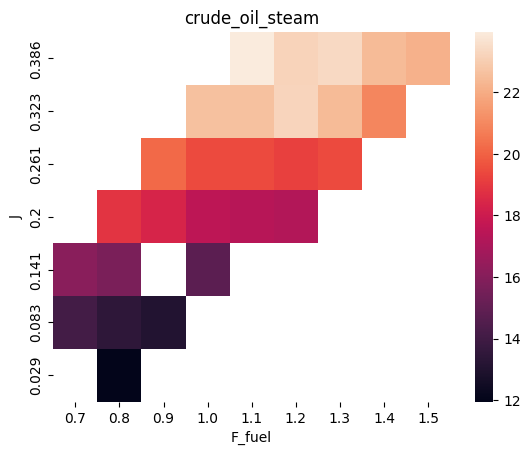

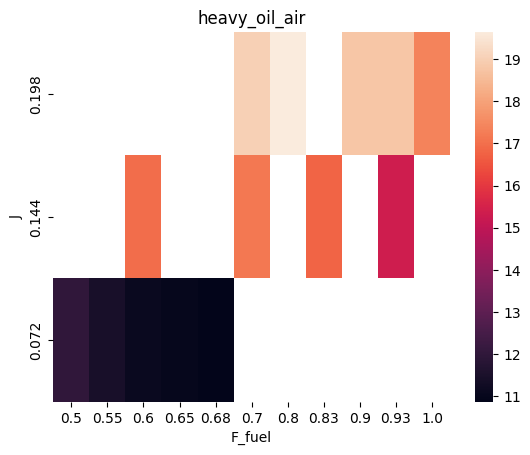

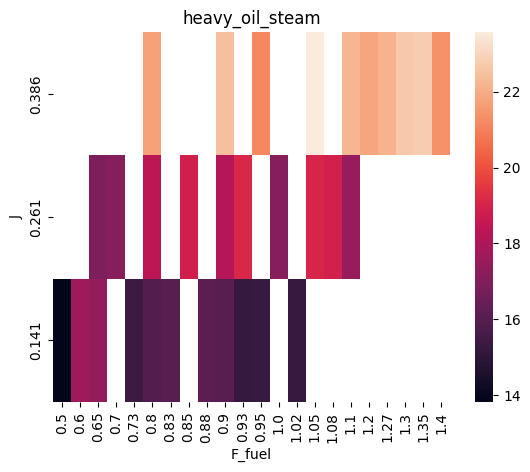

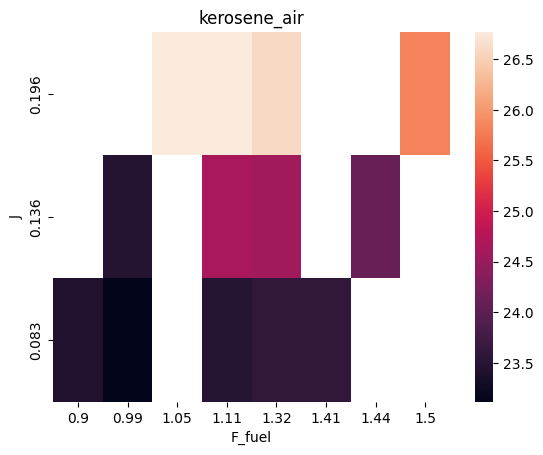

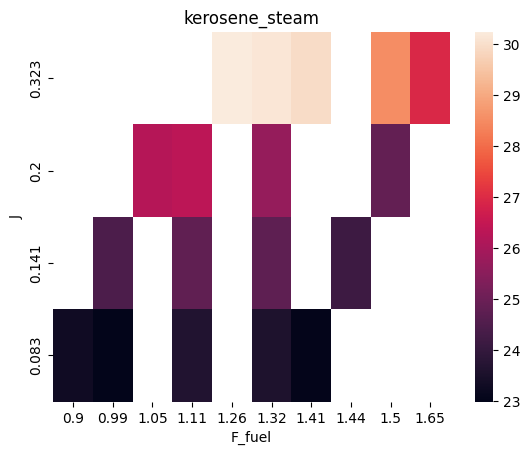

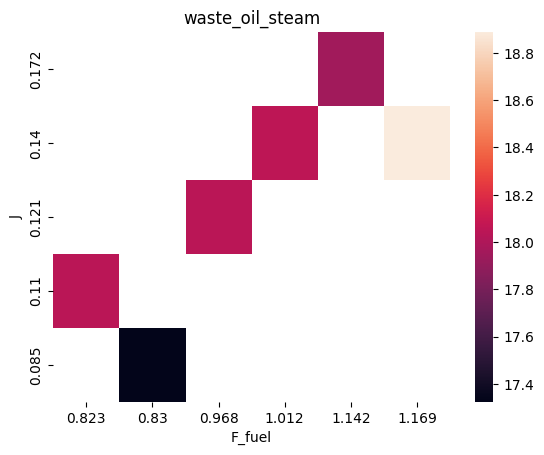

In [9]:
for key in dfs:
    dfs[key] = dfs[key].round(3)
    dfs[key] = dfs[key].dropna(subset=['sum_air'])
    pivoted = dfs[key].pivot_table(index='J', values='sum_air', columns='F_fuel')
    
    ax = sns.heatmap(data=pivoted)
    ax.set_title(key)
    ax.invert_yaxis()
    
    plt.show()
    plt.close()
    

# Разбор ошибок

Почему нет значений расхода топлива > 0.7 у waste_oil?

Потому что отсутствуют значения кислорода по газовому анализу для данного расхода топлива

In [10]:
dfs['waste_oil_steam'][['F_fuel', 'O2']].loc[dfs['waste_oil_steam']['F_fuel'] > 0.71]

,F_fuel,O2
249,0.830,6.505
250,0.968,4.763
251,1.169,2.266
253,0.823,7.197
254,1.012,4.048
255,1.142,1.755


In [11]:
dfs['kerosene_steam'].loc[dfs['kerosene_steam']['sum_air'].notna()]

,experiment_id,fuel_id,F_fuel,F_air,F_steam,O2,CO,NO,NO2,NOx,CO2,SO2,P_air,P_steam,comments,t_wg,flame_height,sum_air,J
218,2374,4,0.99,NaN,0.6,8.656,56.470,22.640,3.580,26.220,9.630,3.633,NaN,4.5,None,24.993,NaN,24.459,0.141
219,2375,4,1.11,NaN,0.6,7.337,29.075,27.613,2.932,30.545,10.640,3.767,NaN,4.5,None,24.492,NaN,24.777,0.141
220,2376,4,1.32,NaN,0.6,4.742,16.387,41.320,2.060,43.380,12.571,6.450,NaN,4.5,None,25.102,NaN,24.762,0.141
221,2377,4,1.44,NaN,0.6,2.829,21.133,46.868,2.170,49.038,14.064,8.650,NaN,4.5,None,25.700,NaN,24.169,0.141
222,2378,4,0.90,NaN,0.4,9.218,64.397,25.590,4.977,30.568,9.227,2.645,NaN,2.8,None,24.926,NaN,23.298,0.083
223,2379,4,0.99,NaN,0.4,7.868,35.797,37.635,3.150,40.785,10.222,4.355,NaN,2.8,None,25.232,NaN,22.993,0.083
224,2380,4,1.11,NaN,0.4,6.679,26.613,43.773,2.797,46.569,11.108,5.000,NaN,2.8,None,25.200,NaN,23.639,0.083
225,2381,4,1.32,NaN,0.4,3.923,23.750,61.826,2.373,64.198,13.195,7.016,NaN,2.8,None,25.734,NaN,23.574,0.083
226,2382,4,1.41,NaN,0.4,2.322,31.267,68.250,2.557,70.807,14.457,8.767,NaN,2.8,None,26.000,NaN,23.024,0.083
227,2383,4,1.05,NaN,0.8,8.789,45.019,15.355,2.352,17.706,9.431,3.000,NaN,6.5,None,25.829,NaN,26.224,0.200


In [12]:
dfs['kerosene_steam'].pivot_table(index='J', values='sum_air', columns='F_fuel')

F_fuel,0.90,0.99,1.05,1.11,1.26,1.32,1.41,1.44,1.50,1.65
J,,,,,,,,,,
0.083,23.298,22.993,NaN,23.639,NaN,23.574,23.024,NaN,NaN,NaN
0.141,NaN,24.459,NaN,24.777,NaN,24.762,NaN,24.169,NaN,NaN
0.200,NaN,NaN,26.224,26.349,NaN,25.683,NaN,NaN,24.833,NaN
0.323,NaN,NaN,NaN,NaN,30.237,30.127,29.951,NaN,28.537,26.941


## Интерполированная поверхность

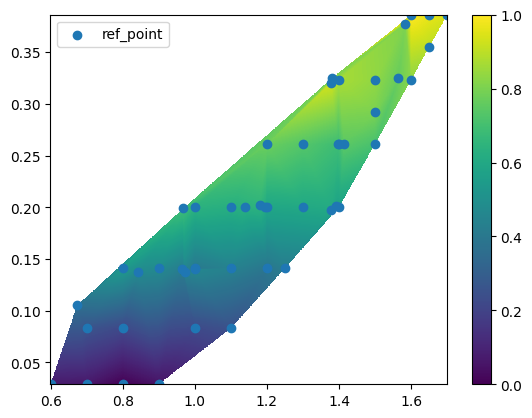

In [13]:
dfs['diesel_steam'] = dfs['diesel_steam'].dropna(subset=['sum_air'])

x = np.array(dfs['diesel_steam']['F_fuel'])
y = np.array(dfs['diesel_steam']['J'])
z = np.array(dfs['diesel_steam']['sum_air'])


X = np.linspace(dfs['diesel_steam']['F_fuel'].min(), dfs['diesel_steam']['F_fuel'].max(), 1_000)
Y = np.linspace(dfs['diesel_steam']['J'].min(), dfs['diesel_steam']['J'].max(), 1_000)
X, Y = np.meshgrid(X, Y)

interp = LinearNDInterpolator(list(zip(x, y)), z)
Z = interp(X, Y)

plt.pcolormesh(X, Y, Z)
plt.scatter(x, y, label='ref_point')
plt.legend()
plt.colorbar()

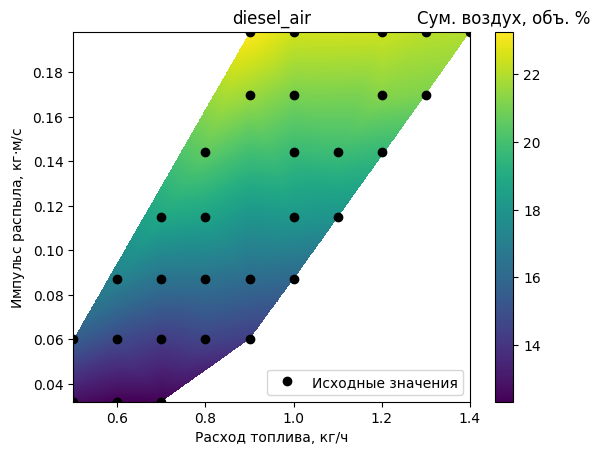

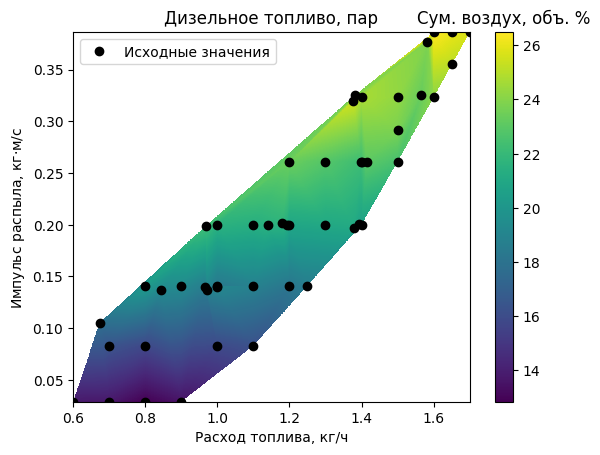

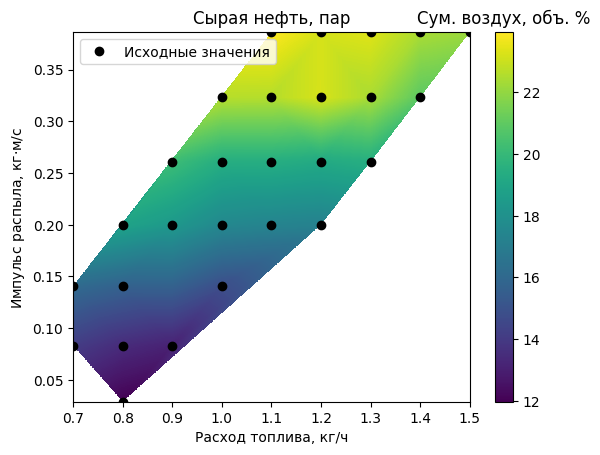

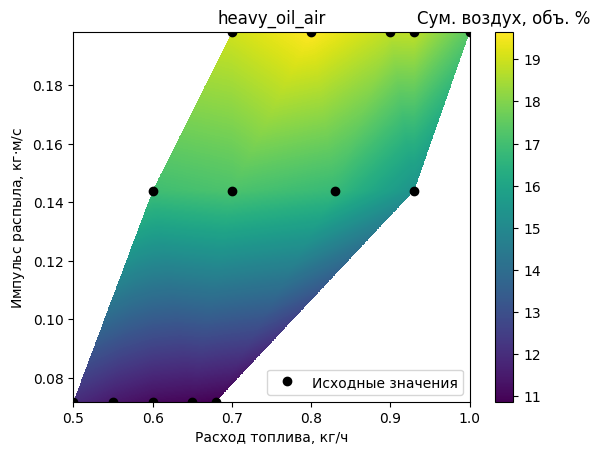

C:\Users\evils\PycharmProjects\approximationMap\venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


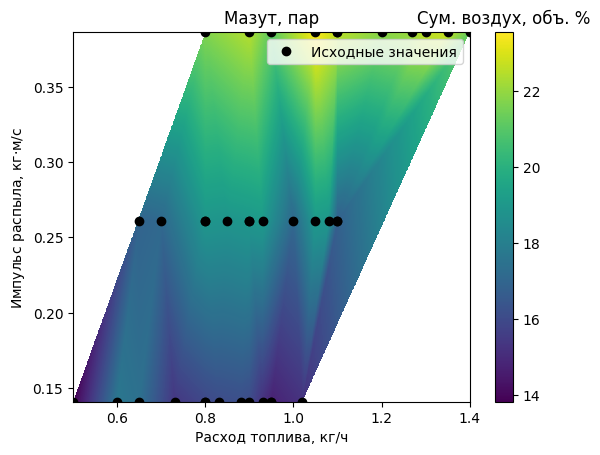

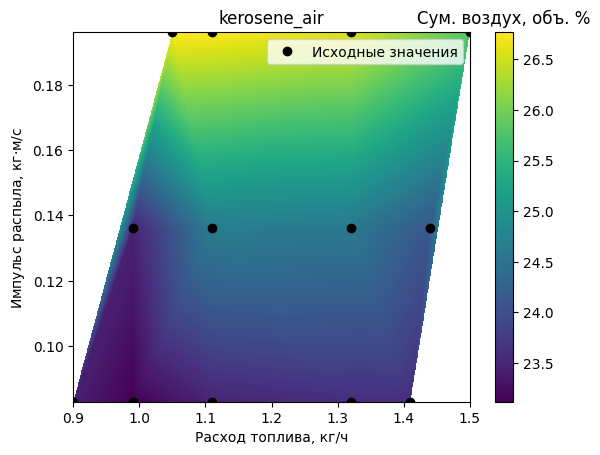

C:\Users\evils\PycharmProjects\approximationMap\venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


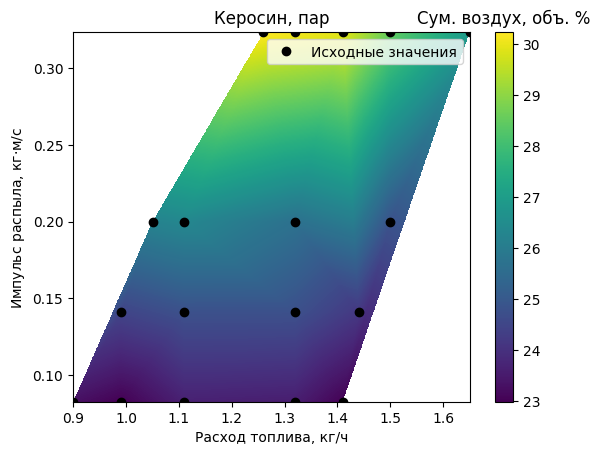

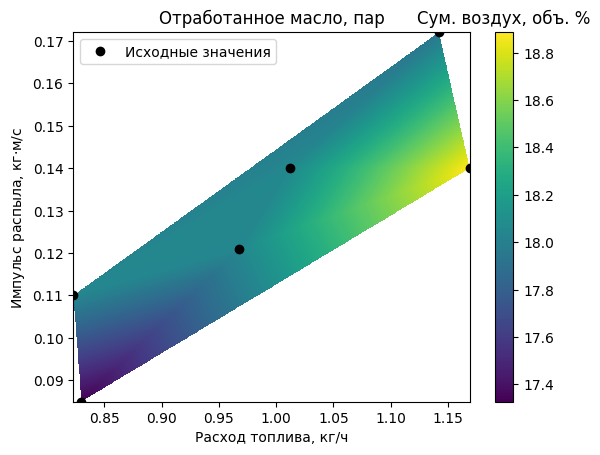

In [25]:
def title_on_russian(title: str) -> str:
    translate = {
        'diesel': 'Дизельное топливо',
        'diesel, CO': 'Дизельное топливо, CO',
        'diesel_steam': 'Дизельное топливо, пар',
        'diesel_steam_CO': 'Дизельное топливо, CO',
        'crude_oil_steam_CO': 'Сырая нефть, CO',
        'crude_oil_steam': 'Сырая нефть, пар',
        'heavy_oil_steam_CO': 'Мазут, CO',
        'heavy_oil_steam': 'Мазут, пар',
        'kerosene_steam_CO': 'Керосин, CO',
        'kerosene_steam': 'Керосин, пар',
        'waste_oil_steam_CO': 'Отработанное масло, CO',
        'waste_oil_steam': 'Отработанное масло, пар',
    }
    return translate.get(title, title)


for key in dfs:
    dfs[key] = dfs[key].round(3)
    dfs[key] = dfs[key].dropna(subset=['sum_air'])
    
    x = np.array(dfs[key]['F_fuel'])
    y = np.array(dfs[key]['J'])
    z = np.array(dfs[key]['sum_air'])

    X = np.linspace(x.min(), x.max(), 1_000)
    Y = np.linspace(y.min(), y.max(), 1_000)
    X, Y = np.meshgrid(X, Y)

    interp = LinearNDInterpolator(list(zip(x, y)), z)
    Z = interp(X, Y)

    fig, ax = plt.subplots()
    
    plt.pcolormesh(X, Y, Z, shading='auto')
    plt.plot(x, y, 'ok', label='Исходные значения')
    plt.legend()
    
    clb = plt.colorbar()
    clb.ax.set_title('Сум. воздух, объ. %')
   
    plt.title(title_on_russian(key))

    ax.set_xlabel('Расход топлива, кг/ч')
    ax.set_ylabel(r'Импульс распыла, кг$\cdot$м/с')
    
    plt.show()
    plt.close()